This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [1]:
!pip install keras keras-hub --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 15.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.32.0 which is incompatible.


In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [3]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Fundamentals of machine learning

### Generalization: The goal of machine learning

#### Underfitting and overfitting

##### Noisy training data

##### Ambiguous features

##### Rare features and spurious correlations

In [16]:
from keras.datasets import mnist
import numpy as np

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255


In [17]:
np.random.random((len(train_images), 784)). shape

(60000, 784)

In [18]:
train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1
)

train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1
)

In [19]:
train_images_with_zeros_channels.shape

(60000, 1568)

In [20]:
import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(512, activation="relu"),
            layers.Dense(10, activation="softmax"), #레이어가 0~9니까
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy", #지난주 내용
        metrics=["accuracy"],
    )
    return model

model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)
#제로 채널 데이터셋
model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)
#오리지날 데이터셋 (수업시간)
model = get_model()
history_original = model.fit(
    train_images,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8663 - loss: 0.4373 - val_accuracy: 0.9122 - val_loss: 0.2873
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9333 - loss: 0.2261 - val_accuracy: 0.9408 - val_loss: 0.1992
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9559 - loss: 0.1527 - val_accuracy: 0.9473 - val_loss: 0.1726
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9671 - loss: 0.1100 - val_accuracy: 0.9546 - val_loss: 0.1575
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9764 - loss: 0.0820 - val_accuracy: 0.9542 - val_loss: 0.1488
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9840 - loss: 0.0569 - val_accuracy: 0.9632 - val_loss: 0.1238
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9886 - loss: 0.0408 - val_accuracy: 0.9615 - val_loss: 0.1303
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9921 - loss: 0.0302 - val_accuracy: 0.

In [10]:
history_noise.history

{'accuracy': [0.8621458411216736,
  0.929854154586792,
  0.9512291550636292,
  0.9665833115577698,
  0.9754583239555359,
  0.9818541407585144,
  0.9881874918937683,
  0.9934583306312561,
  0.9945416450500488,
  0.9970208406448364],
 'loss': [0.4577122628688812,
  0.2362004965543747,
  0.1666836440563202,
  0.11370306462049484,
  0.08392602205276489,
  0.06191270798444748,
  0.04335471987724304,
  0.028107482939958572,
  0.02289721369743347,
  0.015034283511340618],
 'val_accuracy': [0.9268333315849304,
  0.9183333516120911,
  0.9508333206176758,
  0.953666627407074,
  0.9595833420753479,
  0.953083336353302,
  0.9614999890327454,
  0.9645833373069763,
  0.9627500176429749,
  0.9611666798591614],
 'val_loss': [0.2614690661430359,
  0.2661384344100952,
  0.16794714331626892,
  0.15896517038345337,
  0.13936302065849304,
  0.15300212800502777,
  0.13281182944774628,
  0.12371698766946793,
  0.1277904510498047,
  0.14092345535755157]}

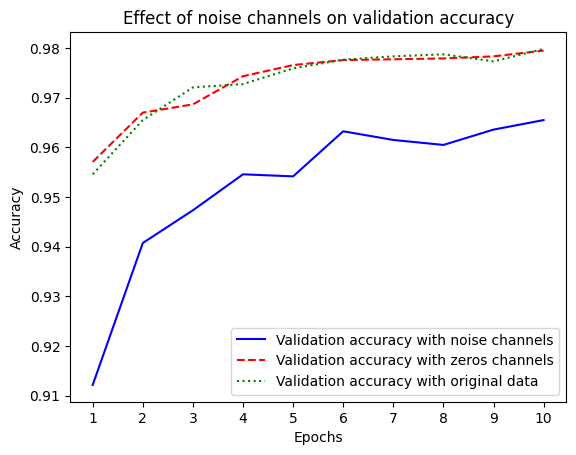

In [26]:
import matplotlib.pyplot as plt

val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]
val_acc_original = history_original.history["val_accuracy"]
epochs = range(1, 11)
plt.plot(
    epochs,
    val_acc_noise,
    "b-",
    label="Validation accuracy with noise channels",
)
plt.plot(
    epochs,
    val_acc_zeros,
    "r--",
    label="Validation accuracy with zeros channels",
    )
#수업시간 오리지널 데이터 accuracy 그리기

plt.plot(
    epochs,
    val_acc_original,
    "g:",
    label="Validation accuracy with original data",
)
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#acuuracy는 매우좋음 / garabage data set을 더할수록 모델이 안좋아질 수  있다.

#### The nature of generalization in deep learning

In [12]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)  #correlation broken됨

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    random_train_labels,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
)

#training accuracy가 늘어나나, validation accuracy는 같다. (0.1 수준)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1035 - loss: 2.3153 - val_accuracy: 0.0997 - val_loss: 2.3065
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1157 - loss: 2.2992 - val_accuracy: 0.1052 - val_loss: 2.3111
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1266 - loss: 2.2914 - val_accuracy: 0.1019 - val_loss: 2.3184
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1414 - loss: 2.2800 - val_accuracy: 0.0994 - val_loss: 2.3321
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1514 - loss: 2.2633 - val_accuracy: 0.0988 - val_loss: 2.3360
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1643 - loss: 2.2442 - val_accuracy: 0.0988 - val_loss: 2.3502
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1783 - loss: 2.2196 - val_accuracy: 0.1018 - val_loss: 2.3566
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1957 - loss: 2.1935 - val_accu

##### The manifold hypothesis

##### Interpolation as a source of generalization

##### Why deep learning works

##### Training data is paramount

### Evaluating machine-learning models

#### Training, validation, and test sets

##### Simple hold-out validation

##### K-fold validation

##### Iterated K-fold validation with shuffling

#### Beating a common-sense baseline

#### Things to keep in mind about model evaluation

### Improving model fit

#### Tuning key gradient descent parameters

In [27]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
#learning rate가 큼 -> 발전 없음
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1041 - loss: 14.4077 - val_accuracy: 0.1081 - val_loss: 14.3760
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1035 - loss: 14.4499 - val_accuracy: 0.1081 - val_loss: 14.3760
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1035 - loss: 14.4499 - val_accuracy: 0.1081 - val_loss: 14.3760
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1035 - loss: 14.4499 - val_accuracy: 0.1081 - val_loss: 14.3760
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1035 - loss: 14.4499 - val_accuracy: 0.1081 - val_loss: 14.3760
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1035 - loss: 14.4499 - val_accuracy: 0.1081 - val_loss: 14.3760
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1035 - loss: 14.4499 - val_accuracy: 0.1081 - val_loss: 14.3760
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1035 - loss: 14.4499 - v

In [28]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
#dataset에 맞춰서 learning rate 조정해줘야함
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9064 - loss: 0.4222 - val_accuracy: 0.9584 - val_loss: 0.1349
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9653 - loss: 0.1270 - val_accuracy: 0.9644 - val_loss: 0.1366
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9735 - loss: 0.0978 - val_accuracy: 0.9664 - val_loss: 0.1540
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9789 - loss: 0.0824 - val_accuracy: 0.9685 - val_loss: 0.1592
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9827 - loss: 0.0689 - val_accuracy: 0.9693 - val_loss: 0.1722
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9848 - loss: 0.0616 - val_accuracy: 0.9698 - val_loss: 0.1809
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9879 - loss: 0.0535 - val_accuracy: 0.9686 - val_loss: 0.1974
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9881 - loss: 0.0492 - val_accuracy: 0.

#### Using better architecture priors

#### Increasing model capacity

In [30]:
model = keras.Sequential([layers.Dense(10, activation="softmax")]) #로지스틱 회귀 모델임
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_small_model = model.fit(
    train_images, train_labels, epochs=20, batch_size=128, validation_split=0.2
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8357 - loss: 0.6703 - val_accuracy: 0.9009 - val_loss: 0.3605
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9031 - loss: 0.3535 - val_accuracy: 0.9132 - val_loss: 0.3099
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9116 - loss: 0.3183 - val_accuracy: 0.9182 - val_loss: 0.2933
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9161 - loss: 0.3022 - val_accuracy: 0.9223 - val_loss: 0.2849
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9187 - loss: 0.2923 - val_accuracy: 0.9203 - val_loss: 0.2806
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9199 - loss: 0.2858 - val_accuracy: 0.9243 - val_loss: 0.2749
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9216 - loss: 0.2808 - val_accuracy: 0.9257 - val_loss: 0.2722
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9228 - loss: 0.2767 - val_accuracy: 0.

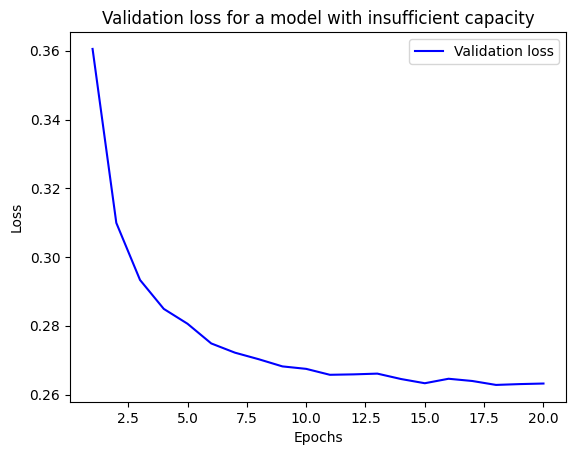

In [31]:
import matplotlib.pyplot as plt

val_loss = history_small_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with insufficient capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

#loss가 낮아짐

In [32]:
model = keras.Sequential(
    [
        #hidden dense layer 2개 추가
        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8998 - loss: 0.3438 - val_accuracy: 0.9427 - val_loss: 0.1889
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9555 - loss: 0.1449 - val_accuracy: 0.9639 - val_loss: 0.1249
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9696 - loss: 0.0991 - val_accuracy: 0.9684 - val_loss: 0.1024
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9780 - loss: 0.0731 - val_accuracy: 0.9705 - val_loss: 0.0974
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9827 - loss: 0.0589 - val_accuracy: 0.9737 - val_loss: 0.0855
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9855 - loss: 0.0463 - val_accuracy: 0.9697 - val_loss: 0.1040
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9887 - loss: 0.0375 - val_accuracy: 0.9749 - val_loss: 0.0937
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9908 - loss: 0.0306 - val_accuracy: 0.

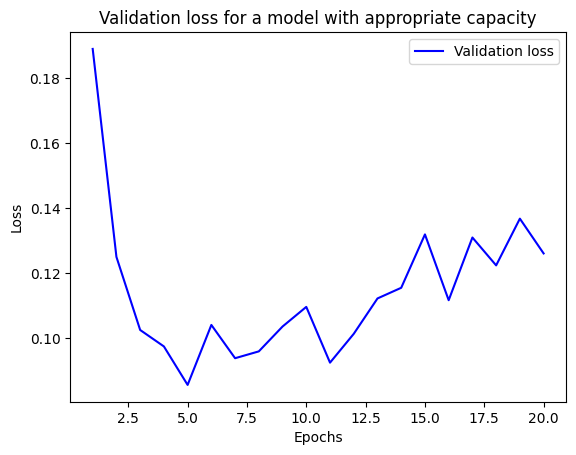

In [33]:
val_loss = history_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with appropriate capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

#val loss가 낮아지다가 갑자기 증가 -> overfitting situation / loss랑 비교하면 loss의 최저는 0.26 그러나 만든 모델에서는 overfitted 되었으나,
#모델이 전반적으로 0.26보다는 낮음 따라서 그래도 적합하다고 할 수 있음

In [34]:
model = keras.Sequential(
    [
        #모델 더 크게 (dense layer 추가)
        layers.Dense(2048, activation="relu"),
        layers.Dense(2048, activation="relu"),
        layers.Dense(2048, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_very_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9260 - loss: 0.2543 - val_accuracy: 0.9628 - val_loss: 0.1352
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9687 - loss: 0.1168 - val_accuracy: 0.9704 - val_loss: 0.1214
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9780 - loss: 0.0874 - val_accuracy: 0.9693 - val_loss: 0.1368
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9836 - loss: 0.0696 - val_accuracy: 0.9732 - val_loss: 0.1289
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9859 - loss: 0.0600 - val_accuracy: 0.9734 - val_loss: 0.1427
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9889 - loss: 0.0490 - val_accuracy: 0.9745 - val_loss: 0.1599
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9907 - loss: 0.0410 - val_accuracy: 0.9771 - val_loss: 0.1381
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9931 - loss: 0.0321 - 

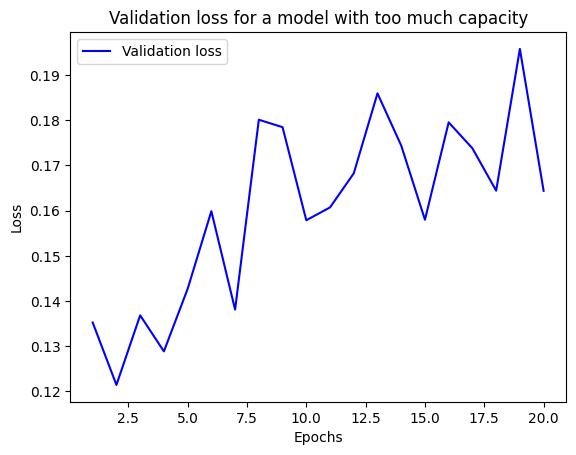

In [36]:
val_loss = history_very_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with too much capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

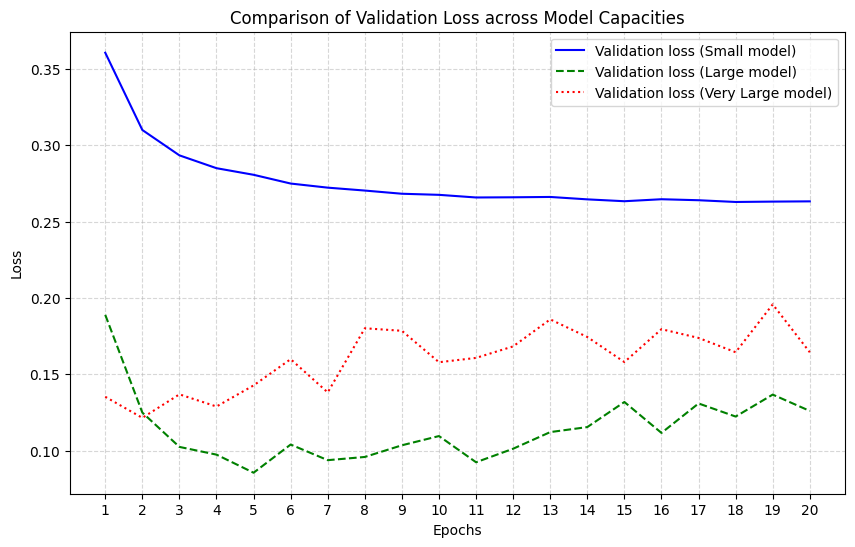

In [35]:
#3개의 모델 다 한눈에 비교하게 plot함
import matplotlib.pyplot as plt

val_loss_small = history_small_model.history["val_loss"]
val_loss_large = history_large_model.history["val_loss"]
val_loss_very_large = history_very_large_model.history["val_loss"]

# Epochs range for plotting (using 20 epochs as they all trained for 20 epochs)
epochs = range(1, 21)

plt.figure(figsize=(10, 6))
plt.plot(epochs, val_loss_small, "b-", label="Validation loss (Small model)")
plt.plot(epochs, val_loss_large, "g--", label="Validation loss (Large model)")
plt.plot(epochs, val_loss_very_large, "r:", label="Validation loss (Very Large model)")

plt.title("Comparison of Validation Loss across Model Capacities")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Improving generalization

#### Dataset curation

#### Feature engineering

#### Using early stopping

#### Regularizing your model

##### Reducing the network's size

In [37]:
from keras.datasets import imdb

(train_data, train_labels), _ = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

train_data = vectorize_sequences(train_data)

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_original = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.7619 - loss: 0.5419 - val_accuracy: 0.8674 - val_loss: 0.4045
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8914 - loss: 0.3329 - val_accuracy: 0.8842 - val_loss: 0.3179
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9202 - loss: 0.2454 - val_accuracy: 0.8758 - val_loss: 0.3084
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9341 - loss: 0.2010 - val_accuracy: 0.8933 - val_loss: 0.2741
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9465 - loss: 0.1669 - val_accuracy: 0.8821 - val_loss: 0.2955
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9557 - loss: 0.1414 - val_accuracy: 0.8887 - val_loss: 0.2846
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9608 - loss: 0.1235 - val_accuracy: 0.8864 - val_loss: 0.2972
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accurac

In [38]:
model = keras.Sequential(
    [
        layers.Dense(4, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_smaller_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.6248 - loss: 0.6388 - val_accuracy: 0.7048 - val_loss: 0.5852
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7483 - loss: 0.5542 - val_accuracy: 0.7836 - val_loss: 0.5375
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8199 - loss: 0.5054 - val_accuracy: 0.8357 - val_loss: 0.5052
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8639 - loss: 0.4695 - val_accuracy: 0.8301 - val_loss: 0.4845
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8957 - loss: 0.4386 - val_accuracy: 0.8557 - val_loss: 0.4625
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9182 - loss: 0.4083 - val_accuracy: 0.8901 - val_loss: 0.4368
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9371 - loss: 0.3763 - val_accuracy: 0.8811 - val_loss: 0.4128
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9455 - loss: 0.3402 - val_accuracy: 0.8771 - v

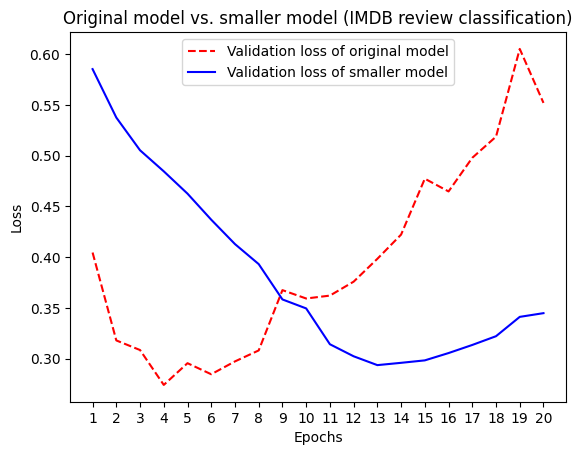

In [39]:
original_val_loss = history_original.history["val_loss"]
smaller_model_val_loss = history_smaller_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    smaller_model_val_loss,
    "b-",
    label="Validation loss of smaller model",
)
plt.title("Original model vs. smaller model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

In [40]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_larger_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.7178 - loss: 0.5707 - val_accuracy: 0.8523 - val_loss: 0.3588
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8582 - loss: 0.3371 - val_accuracy: 0.8792 - val_loss: 0.2941
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9049 - loss: 0.2376 - val_accuracy: 0.8521 - val_loss: 0.3687
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9257 - loss: 0.1925 - val_accuracy: 0.8922 - val_loss: 0.2653
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9471 - loss: 0.1429 - val_accuracy: 0.8891 - val_loss: 0.2859
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9587 - loss: 0.1135 - val_accuracy: 0.8853 - val_loss: 0.3003
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9794 - loss: 0.0631 - val_accuracy: 0.8853 - val_loss: 0.3617
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9795 - loss: 0.0634 - val_accuracy: 0.8838 - v

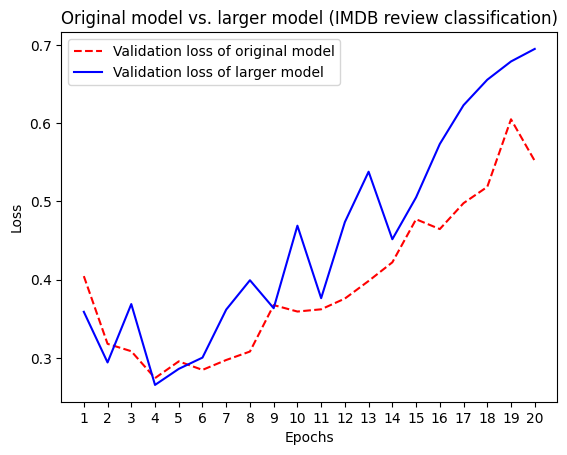

In [41]:
original_val_loss = history_original.history["val_loss"]
larger_model_val_loss = history_larger_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    larger_model_val_loss,
    "b-",
    label="Validation loss of larger model",
)
plt.title("Original model vs. larger model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

#blue overfitting situation이 보임 따라서 red가 낫다

##### Adding weight regularization

In [42]:
from keras.regularizers import l2

model = keras.Sequential(
    [
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.comp  ile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_l2_reg = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7711 - loss: 0.6298 - val_accuracy: 0.8611 - val_loss: 0.4902
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8902 - loss: 0.4206 - val_accuracy: 0.8824 - val_loss: 0.4011
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9087 - loss: 0.3448 - val_accuracy: 0.8798 - val_loss: 0.3782
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9249 - loss: 0.3037 - val_accuracy: 0.8858 - val_loss: 0.3617
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9315 - loss: 0.2789 - val_accuracy: 0.8833 - val_loss: 0.3657
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9379 - loss: 0.2625 - val_accuracy: 0.8659 - val_loss: 0.4122
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9401 - loss: 0.2568 - val_accuracy: 0.8749 - val_loss: 0.3825
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9421 - loss: 0.2484 - val_accuracy: 0.8728 - v

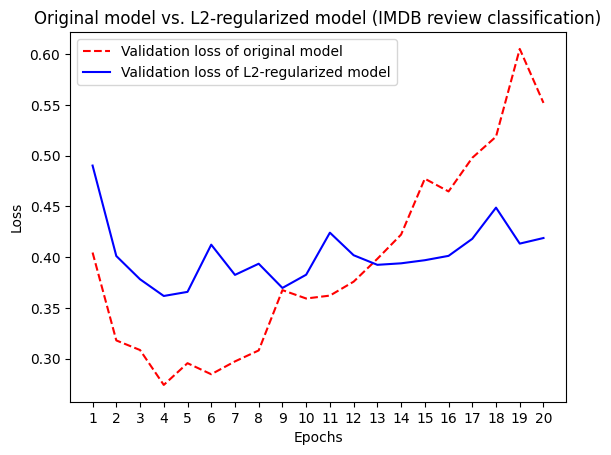

In [43]:
original_val_loss = history_original.history["val_loss"]
l2_val_loss = history_l2_reg.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    l2_val_loss,
    "b-",
    label="Validation loss of L2-regularized model",
)
plt.title(
    "Original model vs. L2-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()
#regularized 모델이 더 나아지지 않음 -> 항상 잘 작동되는 테크닉이 아님
#따라서 밑의 dropout을 더 쓴다

In [44]:
from keras import regularizers

regularizers.l1(0.001)
regularizers.l1_l2(l1=0.001, l2=0.001)

##### Adding dropout

In [52]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_dropout = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.6415 - loss: 0.6326 - val_accuracy: 0.8443 - val_loss: 0.5224
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7697 - loss: 0.5235 - val_accuracy: 0.8710 - val_loss: 0.4226
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8225 - loss: 0.4379 - val_accuracy: 0.8740 - val_loss: 0.3580
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8615 - loss: 0.3782 - val_accuracy: 0.8797 - val_loss: 0.3179
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8890 - loss: 0.3272 - val_accuracy: 0.8886 - val_loss: 0.2882
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9029 - loss: 0.2894 - val_accuracy: 0.8886 - val_loss: 0.2796
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9151 - loss: 0.2570 - val_accuracy: 0.8923 - val_loss: 0.2758
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9250 - loss: 0.2303 - val_accuracy: 0.8892 - v

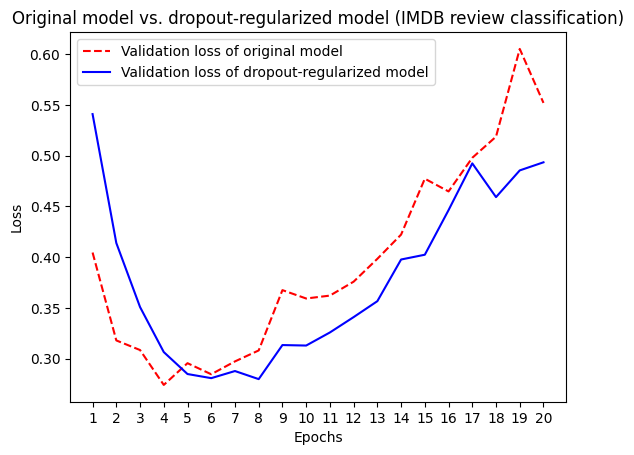

In [46]:
original_val_loss = history_original.history["val_loss"]
dropout_val_loss = history_dropout.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
pit.plot(
    epochs,

)

plt.plot(
    epochs,
    dropout_val_loss,
    "b-",
    label="Validation loss of dropout-regularized model",
)
plt.title(
    "Original model vs. dropout-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()
#loss가 비슷하다면 파란색 모델이 더 낫다

In [58]:
model = keras.Sequential(
    [
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.5),
         layers.Dense(32, activation="relu"),
        layers.Dropout(0.5),
         layers.Dense(32, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_dropout_mine = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 0.5579 - loss: 0.6839 - val_accuracy: 0.7448 - val_loss: 0.6351
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7298 - loss: 0.5934 - val_accuracy: 0.8560 - val_loss: 0.4730
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8236 - loss: 0.4821 - val_accuracy: 0.8489 - val_loss: 0.3981
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8675 - loss: 0.3848 - val_accuracy: 0.8657 - val_loss: 0.3589
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8887 - loss: 0.3228 - val_accuracy: 0.8803 - val_loss: 0.3151
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9089 - loss: 0.2738 - val_accuracy: 0.8801 - val_loss: 0.3110
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9221 - loss: 0.2401 - val_accuracy: 0.8773 - val_loss: 0.3347
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9345 - loss: 0.2094 - val_accuracy: 0.8811 - v

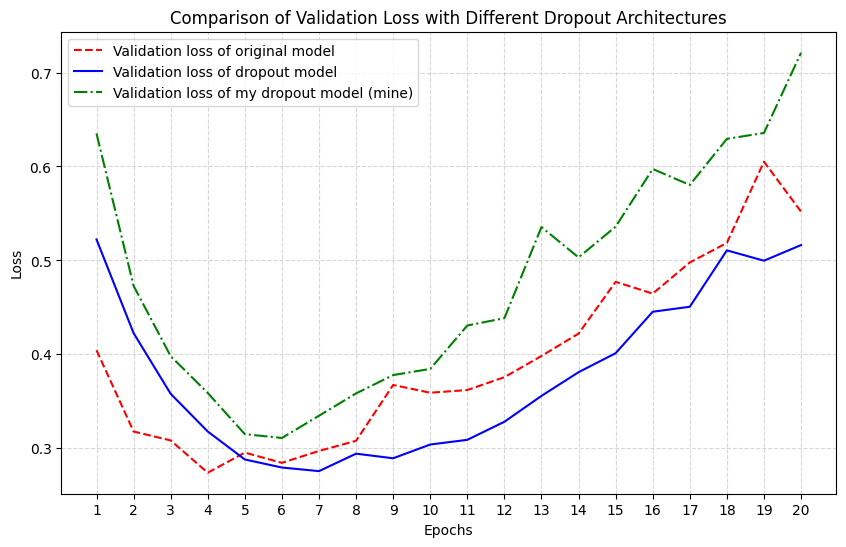

In [59]:
import matplotlib.pyplot as plt

original_val_loss = history_original.history["val_loss"]
dropout_val_loss = history_dropout.history["val_loss"]
mine_val_loss = history_dropout_mine.history["val_loss"]
epochs = range(1, 21)

plt.figure(figsize=(10, 6))
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    dropout_val_loss,
    "b-",
    label="Validation loss of dropout model",
)
plt.plot(
    epochs,
    mine_val_loss,
    "g-.",
    label="Validation loss of my dropout model (mine)",
)

plt.title("Comparison of Validation Loss with Different Dropout Architectures")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

#교수님 거가 더 낫다 내껀 15였음
#오히려 dense layer하나 추가 햇더니 왜 안좋아짐
#과도한 dropout 비율, vanishing gradient, underfiting 등
#뉴런 10 -> 32로 늘림